In [1]:
import glob
import os

import scipy

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from statsmodels.stats.multitest import multipletests

# Data loading

In [24]:
INPUT_DIR = "/Users/willtrim/Documents/projs/bedrest/outputs/"

## Correlations

In [192]:
cors_dir = "/Users/willtrim/Documents/projs/bedrest/outputs/cors2/"

cors_fps = glob.glob(os.path.join(cors_dir, "*_*.csv"))

cors = {}

cols = ["converted_alias", "name", "description"]

for cors_fp in cors_fps:
    tmp, phen = os.path.basename(cors_fp).split(".")[0].split("_", maxsplit=1)

    tmp_phen_cors = pd.read_csv(cors_fp)

    tmp_phen_cors["ensembl_gene_id"] = tmp_phen_cors.gene.str.split(".", expand=True).iloc[:,0]
    
    tmp_phen_cors[cols] = None
    idx = tmp_phen_cors.ensembl_gene_id.isin(gene_names_.index)
    tmp_phen_cors.loc[idx, cols] = gene_names_.loc[tmp_phen_cors.loc[idx, "ensembl_gene_id"], cols].values
    
    if phen in cors:
        cors[phen][tmp] = tmp_phen_cors
    else:
        cors[phen] = {tmp: tmp_phen_cors} 

    # break

## Gene sets

In [2]:
genesets_dir = "/Users/willtrim/Documents/reference/msigdb/msigdb_v2025.1.Hs_GMTs/"

genesets_fps = glob.glob(os.path.join(genesets_dir, "*.tsv"))

In [3]:
genesets = {}

for genesets_fp in genesets_fps:
    
    db_name = os.path.basename(genesets_fp).split(".")[0]
    
    db_genesets = pd.read_csv(genesets_fp, sep="\t", index_col=0)
    
    db_genesets.pathways = db_genesets.pathways.str.split(", ").map(set)

    genesets[db_name] = db_genesets

In [4]:
from functools import reduce

all_genesets_genes = set()

for db_name, db_genesets in genesets.items():
    all_genesets_genes |= reduce(lambda a, b: a | b, db_genesets.pathways)

In [5]:
len(all_genesets_genes)

20835

## Gene entrez ids

In [6]:
rlog_fp = os.path.join(INPUT_DIR, "rlog_counts_star_rsem.csv")

rlog = pd.read_csv(rlog_fp, index_col=0)
rlog.head()

,A1_Post,A2_Post,B1_Post,B2_Post,C1_Post,C2_Post,D1_Post,D2_Post,E1_Post,E2_Post,...,F1_Pre,F2_Pre,G1_Pre,G2_Pre,H1_Pre,H2_Pre,I1_Pre,I2_Pre,J1_Pre,J2_Pre
ENSG00000000003.16,10.441921,10.445695,10.129874,10.407166,10.471710,10.332573,10.475635,10.371279,10.271373,10.478572,...,10.624568,10.406151,10.390147,10.375603,10.477752,10.546246,10.341907,10.286274,10.390158,10.528786
ENSG00000000005.6,8.866141,9.707402,8.760895,9.202013,9.195625,9.546052,9.231500,8.893196,9.588682,9.701247,...,9.570189,9.421571,9.532899,8.976220,9.199024,9.235549,10.564737,9.264435,9.285173,9.000341
ENSG00000000419.14,9.649389,9.530534,9.837392,9.724397,9.756636,9.603278,9.663451,9.706612,9.574476,9.587087,...,9.581840,9.648275,9.629305,9.699160,9.912812,9.681877,9.539867,9.670682,9.580647,9.684913
ENSG00000000457.14,8.870346,8.738457,9.048945,8.681763,9.015666,8.724369,8.910953,8.897573,8.923367,8.787728,...,8.848077,8.845071,8.906610,8.961840,8.824269,8.874319,8.880181,8.854554,8.810754,8.941380
ENSG00000000460.17,6.744174,6.579216,6.661595,6.299408,6.381015,6.585593,6.538086,6.640206,6.525538,6.582556,...,6.550203,6.407576,6.513301,6.511696,6.484146,6.452780,6.741276,6.349335,6.665601,6.655332


In [7]:
gene_ids = rlog.index.to_series().str.split(".", expand=True).iloc[:,0]

In [8]:
# print(" ".join(gene_ids))

In [8]:
gene_names = pd.read_csv(os.path.join(INPUT_DIR, "gProfiler_hsapiens_31-01-2026_21-57-11.csv"), dtype={1: str})
gene_names

,initial_alias,converted_alias,name,description,namespace
0,ENSG00000000003,7105,TSPAN6,tetraspanin 6 [Source:HGNC Symbol;Acc:HGNC:11858],"ARRAYEXPRESS,ENSG,HPA,HPA_ACC"
1,ENSG00000000005,64102,TNMD,tenomodulin [Source:HGNC Symbol;Acc:HGNC:17757],"ARRAYEXPRESS,ENSG,HPA,HPA_ACC"
2,ENSG00000000419,8813,DPM1,dolichyl-phosphate mannosyltransferase subunit...,"ARRAYEXPRESS,ENSG,HPA,HPA_ACC"
3,ENSG00000000457,57147,SCYL3,SCY1 like pseudokinase 3 [Source:HGNC Symbol;A...,"ARRAYEXPRESS,ENSG,HPA,HPA_ACC"
4,ENSG00000000460,55732,FIRRM,FIGNL1 interacting regulator of recombination ...,"ARRAYEXPRESS,ENSG,HPA,HPA_ACC"
...,...,...,...,...,...
25951,ENSG00000310537,NaN,NaN,NaN,NaN
25952,ENSG00000310539,100887824,DDX11L2,DEAD/H-box helicase 11 like 2 (pseudogene) [So...,"ARRAYEXPRESS,ENSG"
25953,ENSG00000310539,84771,DDX11L2,DEAD/H-box helicase 11 like 2 (pseudogene) [So...,"ARRAYEXPRESS,ENSG"
25954,ENSG00000310560,NaN,NaN,NaN,NaN


In [9]:
gene_names.value_counts("initial_alias")

initial_alias
ENSG00000278233    208
ENSG00000278189    208
ENSG00000275215    208
ENSG00000277739    207
ENSG00000205457      6
                  ... 
ENSG00000001561      1
ENSG00000001617      1
ENSG00000001629      1
ENSG00000001630      1
ENSG00000001631      1
Name: count, Length: 24834, dtype: int64

In [10]:
gene_names_ = gene_names.loc[gene_names.converted_alias.isin(all_genesets_genes),:]

In [11]:
(gene_names_.value_counts("initial_alias") > 1).sum()

np.int64(64)

In [12]:
gene_names_ = gene_names_.sort_values("name").drop_duplicates("initial_alias", keep="first")

In [13]:
gene_names_.set_index("initial_alias", inplace=True)

In [14]:
gene_names_.head()

,converted_alias,name,description,namespace
initial_alias,,,,
ENSG00000277739,124907149,5_8S_rRNA,5.8S ribosomal RNA [Source:RFAM;Acc:RF00002],"ARRAYEXPRESS,ENSG"
ENSG00000121410,1,A1BG,alpha-1-B glycoprotein [Source:HGNC Symbol;Acc...,"ARRAYEXPRESS,ENSG,HPA,HPA_ACC"
ENSG00000175899,2,A2M,alpha-2-macroglobulin [Source:HGNC Symbol;Acc:...,"ARRAYEXPRESS,ENSG,HPA,HPA_ACC"
ENSG00000128274,53947,A4GALT,"alpha 1,4-galactosyltransferase (P1PK blood gr...","ARRAYEXPRESS,ENSG,HPA,HPA_ACC"
ENSG00000094914,8086,AAAS,aladin WD repeat nucleoporin [Source:HGNC Symb...,"ARRAYEXPRESS,ENSG,HPA,HPA_ACC"


In [22]:
gene_names_ = gene_names_.drop_duplicates("converted_alias", keep="first")

converted_alias
100037417    2
9782         2
8916         2
883          2
8622         2
            ..
9969         1
997          1
9972         1
9973         1
100101490    1
Name: count, Length: 14933, dtype: int64

## Phenotypes

In [15]:
pheno = pd.read_csv(os.path.join(INPUT_DIR, "BedRest_blood_phenotype.csv"))
pheno.head()

,Participant ID,Group,Time Point,Venous Glucose (mmol/L),Venous Insulin (mU/L),Art. Glucose (mmol/L),Fat ox/kg,cho ox/Kg,FFA (mmol/L),TAG (mmol/L),Art. Insulin (mIU/L),Glucose Disposal
0,A1,Cocktail,Pre Bed Rest,4.8840,2.8600,4.30,1.887698,0.318964,0.415,0.58,4.70,8.520406
1,B1,Cocktail,Pre Bed Rest,4.8285,3.2250,4.16,1.321354,1.248777,0.390,0.46,5.90,6.175030
2,C1,Control,Pre Bed Rest,4.8840,7.1990,4.26,1.787597,0.315102,0.554,0.51,12.62,6.301969
3,D1,Control,Pre Bed Rest,4.9950,4.5270,4.63,1.950858,NaN,0.949,0.40,12.57,4.914221
4,E1,Control,Pre Bed Rest,4.6620,3.6575,4.45,1.391448,0.888337,0.427,1.24,19.94,5.444510


## TPM counts

In [25]:
tpm_fp = os.path.join(INPUT_DIR, "rsem.merged.gene_tpm.tsv")
tpm = pd.read_csv(tpm_fp, sep="\t")
tpm = tpm.drop("transcript_id(s)", axis=1).set_index("gene_id")
tpm.head()

,SRR15503376_GSM5526409_A1_POST_Homo_sapiens_RNA-Seq,SRR15503377_GSM5526410_A2_POST_Homo_sapiens_RNA-Seq,SRR15503378_GSM5526411_B1_POST_Homo_sapiens_RNA-Seq,SRR15503379_GSM5526412_B2_POST_Homo_sapiens_RNA-Seq,SRR15503380_GSM5526413_C1_POST_Homo_sapiens_RNA-Seq,SRR15503381_GSM5526414_C2_POST_Homo_sapiens_RNA-Seq,SRR15503382_GSM5526415_D1_POST_Homo_sapiens_RNA-Seq,SRR15503383_GSM5526416_D2_POST_Homo_sapiens_RNA-Seq,SRR15503384_GSM5526417_E1_POST_Homo_sapiens_RNA-Seq,SRR15503385_GSM5526418_E2_POST_Homo_sapiens_RNA-Seq,...,SRR15503406_GSM5526439_F1_PRE_Homo_sapiens_RNA-Seq,SRR15503407_GSM5526440_F2_PRE_Homo_sapiens_RNA-Seq,SRR15503408_GSM5526441_G1_PRE_Homo_sapiens_RNA-Seq,SRR15503409_GSM5526442_G2_PRE_Homo_sapiens_RNA-Seq,SRR15503410_GSM5526443_H1_PRE_Homo_sapiens_RNA-Seq,SRR15503411_GSM5526444_H2_PRE_Homo_sapiens_RNA-Seq,SRR15503412_GSM5526445_I1_PRE_Homo_sapiens_RNA-Seq,SRR15503413_GSM5526446_I2_PRE_Homo_sapiens_RNA-Seq,SRR15503414_GSM5526447_J1_PRE_Homo_sapiens_RNA-Seq,SRR15503415_GSM5526448_J2_PRE_Homo_sapiens_RNA-Seq
gene_id,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003.16,23.12,25.38,16.35,22.63,24.90,20.33,23.86,20.79,18.26,23.64,...,28.68,22.26,23.74,20.39,21.64,24.37,21.94,17.92,19.73,26.51
ENSG00000000005.6,23.46,61.87,20.27,34.22,35.02,47.29,34.72,23.35,47.23,55.45,...,51.00,42.34,51.40,24.97,30.38,33.19,135.26,32.71,33.11,28.57
ENSG00000000419.14,41.56,40.17,49.03,45.49,48.48,38.92,42.05,42.57,36.13,38.40,...,40.04,41.44,44.04,41.25,49.10,40.79,38.96,38.57,34.80,45.30
ENSG00000000457.14,5.39,5.12,6.33,4.46,6.56,4.52,5.61,5.35,5.35,4.86,...,5.44,5.23,6.06,5.60,4.63,5.14,5.72,4.81,4.55,6.10
ENSG00000000460.17,2.55,2.23,2.22,1.38,1.60,2.01,1.92,2.14,1.77,2.02,...,2.02,1.59,2.01,1.75,1.61,1.62,2.65,1.33,2.06,2.37


In [30]:
min_expression = 0
min_samples = 5

gene_expressed = (tpm > min_expression).sum(axis=1) > min_samples

gene_expressed.shape, gene_expressed.sum()

((78686,), np.int64(34193))

## Rlog counts

In [125]:
rlog = pd.read_csv("/Users/willtrim/Documents/projs/bedrest/outputs/rlog_counts_star_rsem.csv", index_col=0)
rlog.head()

,A1_Post,A2_Post,B1_Post,B2_Post,C1_Post,C2_Post,D1_Post,D2_Post,E1_Post,E2_Post,...,F1_Pre,F2_Pre,G1_Pre,G2_Pre,H1_Pre,H2_Pre,I1_Pre,I2_Pre,J1_Pre,J2_Pre
ENSG00000000003.16,10.441921,10.445695,10.129874,10.407166,10.471710,10.332573,10.475635,10.371279,10.271373,10.478572,...,10.624568,10.406151,10.390147,10.375603,10.477752,10.546246,10.341907,10.286274,10.390158,10.528786
ENSG00000000005.6,8.866141,9.707402,8.760895,9.202013,9.195625,9.546052,9.231500,8.893196,9.588682,9.701247,...,9.570189,9.421571,9.532899,8.976220,9.199024,9.235549,10.564737,9.264435,9.285173,9.000341
ENSG00000000419.14,9.649389,9.530534,9.837392,9.724397,9.756636,9.603278,9.663451,9.706612,9.574476,9.587087,...,9.581840,9.648275,9.629305,9.699160,9.912812,9.681877,9.539867,9.670682,9.580647,9.684913
ENSG00000000457.14,8.870346,8.738457,9.048945,8.681763,9.015666,8.724369,8.910953,8.897573,8.923367,8.787728,...,8.848077,8.845071,8.906610,8.961840,8.824269,8.874319,8.880181,8.854554,8.810754,8.941380
ENSG00000000460.17,6.744174,6.579216,6.661595,6.299408,6.381015,6.585593,6.538086,6.640206,6.525538,6.582556,...,6.550203,6.407576,6.513301,6.511696,6.484146,6.452780,6.741276,6.349335,6.665601,6.655332


In [126]:
rlog = rlog.loc[rlog.index.isin(gene_expressed.index),:]

In [127]:
gene_ids = rlog.index.to_series().str.extract("(^\w+)")

idx = gene_ids[0].isin(gene_names_.index)
gene_ids[gene_names_.columns] = None
gene_ids.loc[idx, gene_names_.columns] = gene_names_.loc[gene_ids.loc[idx, 0], gene_names_.columns].values

<>:1: SyntaxWarning: invalid escape sequence '\w'
<>:1: SyntaxWarning: invalid escape sequence '\w'
/var/folders/w5/5q2ysxtd5vv9bc1cf7bhf07w0000gn/T/ipykernel_33659/3226964536.py:1: SyntaxWarning: invalid escape sequence '\w'
  gene_ids = rlog.index.to_series().str.extract("(^\w+)")


In [128]:
rlog["entrez_id"] = gene_ids.loc[rlog.index, "converted_alias"]

In [129]:
vc = rlog.value_counts("entrez_id")
# rlog.loc[rlog.entrez_id.isin(vc[(vc > 1)].index),:].sort_values("entrez_id").head(30)

In [130]:
rlog = rlog.drop_duplicates("entrez_id", keep=False)
rlog.set_index("entrez_id", inplace=True)

In [131]:
remove_samples = ["I2_Post", ]
rlog = rlog.loc[:,~rlog.columns.isin(remove_samples)]

In [132]:
rlog_post = rlog[rlog.columns[rlog.columns.to_series().str.endswith("_Post")]]
rlog_pre = rlog[rlog.columns[rlog.columns.to_series().str.endswith("_Pre")]]

In [133]:
rlog_post.columns = rlog_post.columns.to_series().str.replace("_Post", "")
rlog_pre.columns = rlog_pre.columns.to_series().str.replace("_Pre", "")

# TCA cycle vs Arterial insulin post

In [134]:
tca_genes = genesets["KEGG"].loc["Citrate cycle (TCA cycle)", "pathways"]

tca_post = rlog_post.loc[rlog_post.index.isin(tca_genes),:].T
tca_post.head()

entrez_id,4190,1431,3421,6389,1738,2271,50,5106,3420,4967,...,6391,4191,1737,8802,3419,5162,8801,5091,3418,6392
A1,12.836103,13.690312,9.990257,11.760757,11.805824,10.897269,12.228472,10.324282,10.728319,12.253855,...,11.218526,11.587786,10.911891,11.769960,10.633352,10.727518,11.370468,12.813125,11.309134,11.554474
A2,12.646969,13.022538,9.853861,11.501905,11.506915,10.584953,11.875516,10.143070,10.509571,11.921344,...,11.016532,11.087320,10.390942,11.434886,10.395395,10.514432,11.030751,12.179320,10.524823,11.250794
B1,12.863628,13.731661,10.066736,12.139049,11.961116,11.065530,12.359457,10.828231,10.836961,12.208386,...,11.287633,11.575129,11.046598,11.819483,10.518779,10.761893,11.542849,12.932880,11.454667,11.702405
B2,12.976301,13.330523,9.894964,11.834713,11.644036,10.759937,12.172014,10.246882,10.751422,12.035855,...,11.096352,11.296185,10.406864,11.892655,10.661695,10.791152,11.149652,12.482689,10.906800,11.491278
C1,13.235032,13.332760,9.949070,11.729629,11.771511,10.772837,12.213600,10.475172,10.720847,12.233647,...,11.241222,11.396623,10.698014,11.858027,10.865870,10.660048,11.372990,12.572829,10.663934,11.540265


In [135]:
tca_post = (tca_post - tca_post.mean(axis=0)) / tca_post.std(axis=0)

In [136]:
pheno_names = ["Art. Insulin (mIU/L)",]
tmp_col = "Time Point"
id_col = "Participant ID"

pheno_df = pheno.loc[pheno[tmp_col] == "Post Bed Rest", :].set_index(id_col).loc[:,pheno_names]

In [137]:
pheno_df = (pheno_df - pheno_df.mean(axis=0)) / pheno_df.std(axis=0)

In [138]:
gene_pheno_df = pd.merge(pheno_df, tca_post, left_index=True, right_index=True)

In [139]:
gene_pheno_df

,Art. Insulin (mIU/L),4190,1431,3421,6389,1738,2271,50,5106,3420,...,6391,4191,1737,8802,3419,5162,8801,5091,3418,6392
A1,-2.350320,-0.613090,1.469107,0.614652,-0.109295,0.560345,0.881822,0.445373,0.088250,0.479405,...,0.470445,1.324116,1.020142,0.455418,0.114136,0.047667,0.867669,0.827845,1.151303,0.723466
B1,-1.564578,-0.511985,1.651496,1.385122,1.975504,1.704969,2.116720,1.262728,1.414129,1.419053,...,1.053548,1.253286,1.623000,0.799610,-0.425758,0.275702,1.924607,1.360230,1.540404,1.841881
C1,-0.935371,0.852257,-0.108051,0.199713,-0.280845,0.307433,-0.031401,0.352568,0.485241,0.414784,...,0.661946,0.254398,0.062968,1.067494,1.209807,-0.399907,0.883128,-0.240422,-0.573713,0.616045
D1,0.138886,-0.553382,-0.847994,-1.345485,0.009585,-0.840204,-0.294545,-0.527434,-0.891341,-0.681590,...,-2.218354,-0.704905,-1.614414,-1.240871,-1.162458,-1.923265,0.577154,-0.270536,-0.317885,-0.945181
E1,0.999826,1.053473,-1.288654,-0.005637,-1.685489,-1.493767,-1.854417,-1.527642,-1.270367,-1.618938,...,-1.439809,-1.824937,-1.551467,-1.468061,-1.071838,-1.587630,-1.178471,-0.591305,-1.896190,-1.677572
F1,0.115866,1.777032,-1.387050,-0.141955,-0.008483,-0.296263,-1.242011,-1.689000,-0.876443,-0.540450,...,-0.338568,-0.800372,-0.588844,-1.415230,-0.002451,-1.596190,-0.926721,-1.042490,-1.067062,-1.145049
G1,0.049876,0.909326,-0.974508,0.364821,0.203432,-1.253224,-1.059353,-1.765390,-0.073094,-1.860174,...,-0.665370,-0.757576,-0.974979,-0.033941,-0.292946,-0.689337,-0.654889,-1.326512,-0.631539,-0.507602
H1,-0.771163,-1.022998,1.761465,2.451136,-2.295605,1.237810,1.941109,1.584212,1.298300,2.242321,...,1.216511,2.059968,0.282462,0.790725,-0.505933,1.072423,1.154570,1.681131,1.730064,0.999678
I1,1.357400,-0.057150,-0.602277,-0.441829,0.819490,-1.379945,-0.226339,0.319873,-2.343104,0.308498,...,1.379616,-0.944156,-0.244737,0.237291,0.086949,0.207982,-1.716956,-1.390391,-1.223126,-0.346546
J1,-0.195668,-1.204229,-0.292442,-0.461995,0.638008,0.300582,0.004956,0.350845,0.457696,-0.514260,...,0.195632,-0.261407,1.458730,0.115049,-0.260292,0.494239,-0.294867,0.384354,0.098723,0.242177


In [140]:
gene_pheno_df.sort_values(pheno_names[0], inplace=True)

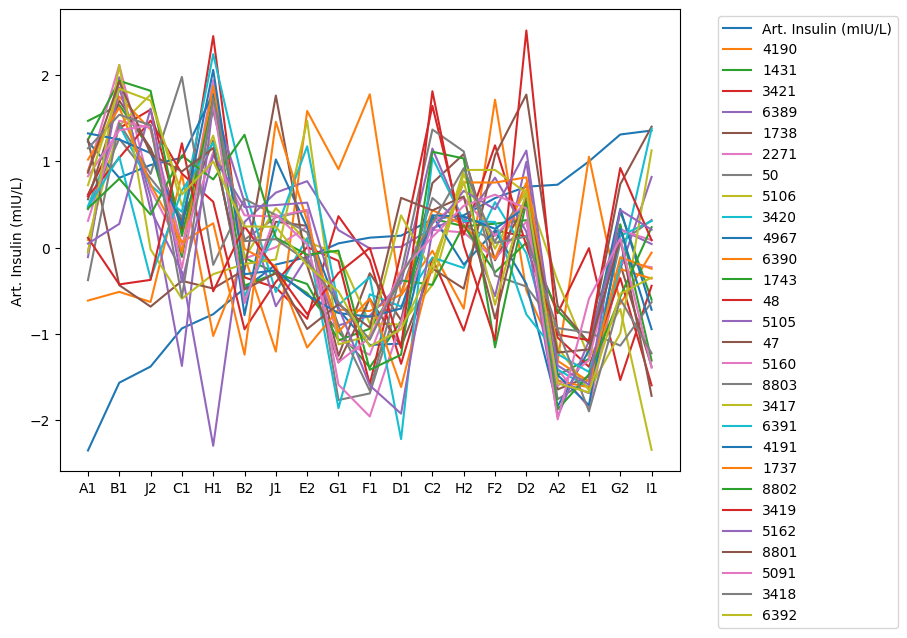

In [141]:
fig, ax = plt.subplots(figsize=(8, 6))

n = gene_pheno_df.shape[0]
x = list(range(n))

for col in gene_pheno_df.columns:
    sns.lineplot(x=x, y=gene_pheno_df[col], label=col)

_ = plt.xticks(x, gene_pheno_df.index)
_ = plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

In [104]:
import scipy as sc

In [142]:
cols = gene_pheno_df.columns
phenotypes_hor = gene_pheno_df

phenotype_cor = np.eye(len(cols))
phenotype_cor_pval = np.zeros((len(cols), len(cols)))

for i, col1 in enumerate(cols):
    
    phen1 = phenotypes_hor[col1]
    phen1_na = phen1.isna()
    
    for j in range(i):
        
        phen2 = phenotypes_hor[cols[j]]
        phen2_na = phen2.isna()
        idx = ~(phen1_na | phen2_na)
        # cor = sc.stats.pearsonr(phen1.loc[idx], phen2.loc[idx])
        cor = sc.stats.spearmanr(phen1.loc[idx], phen2.loc[idx], nan_policy="omit")
        phenotype_cor[i, j] = cor.statistic
        phenotype_cor[j, i] = cor.statistic
        phenotype_cor_pval[i, j] = cor.pvalue
        phenotype_cor_pval[j, i] = cor.pvalue

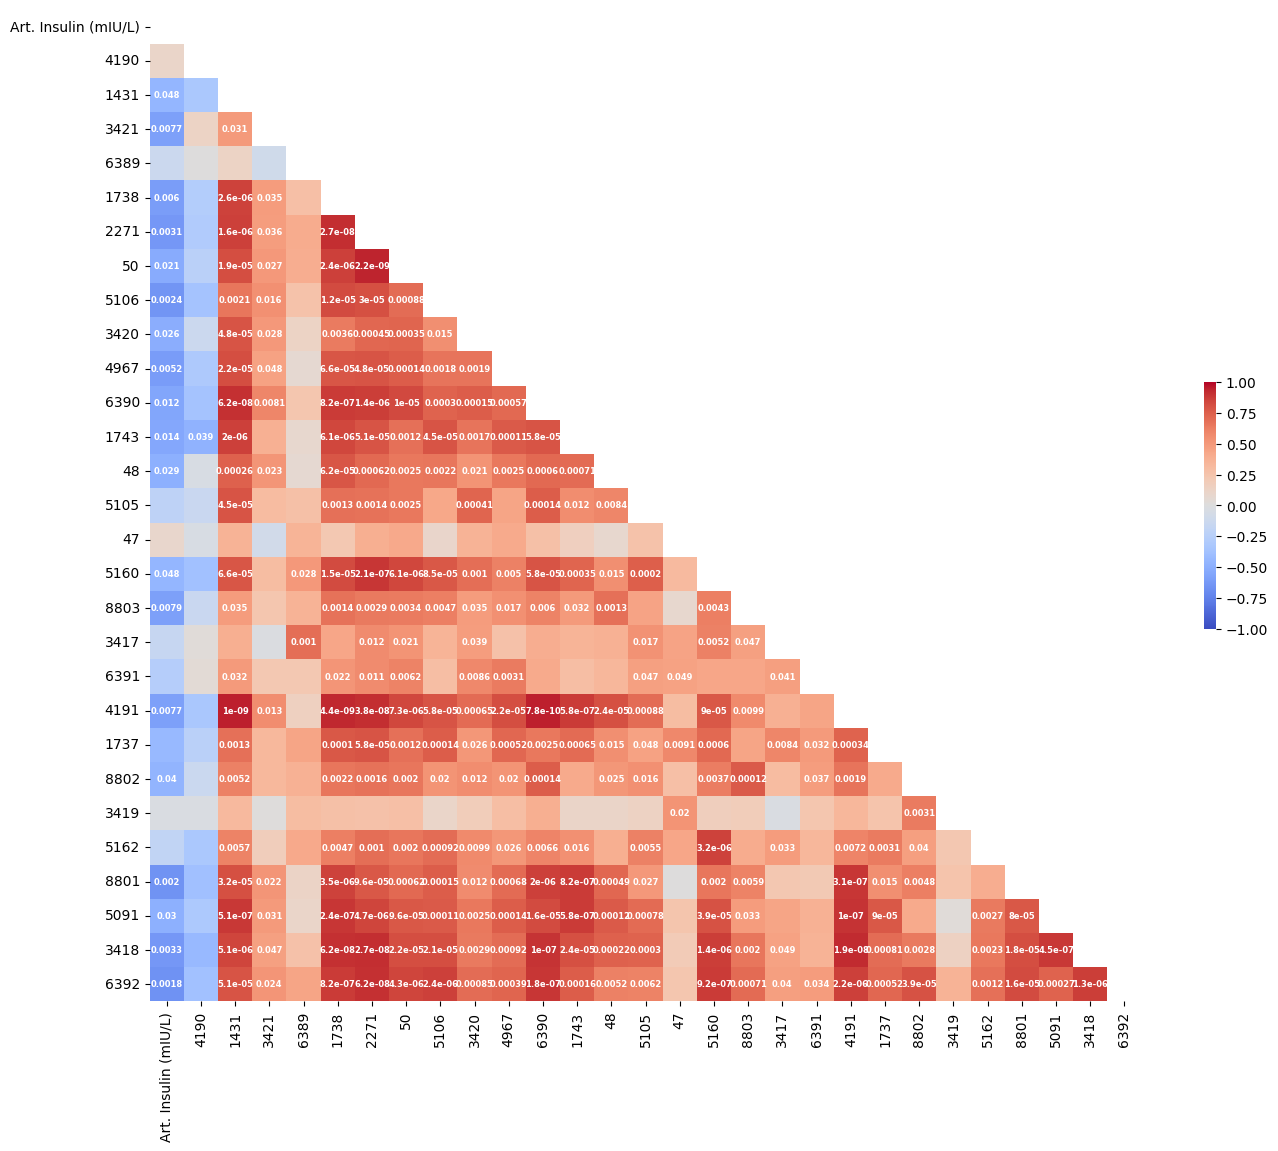

In [143]:
mask = np.triu(np.ones_like(phenotype_cor, dtype=bool))

fig, ax = plt.subplots(figsize=(16, 16))

sns.heatmap(
    phenotype_cor,
    square=True,
    cmap="coolwarm",
    xticklabels=cols,
    yticklabels=cols,
    annot=phenotype_cor_pval,
    annot_kws={"fontsize": 6, "color": "#ebebeb"}, 
    mask=mask,
    ax=ax,
    cbar_kws={"shrink": 0.2, 'location': 'right'},
    vmax=1,
    vmin=-1
)

significance_mask = phenotype_cor_pval < 0.05

i = 1
j = 0
for k, text in enumerate(ax.texts):
    if significance_mask[i, j]:
        text.set_weight('bold')
        text.set_color('white')
        text.set_fontsize(6)
    else:
        text.set_visible(False)
    j += 1 
    if j == i:
        i += 1
        j = 0

## Solo genes test results

In [145]:
res_dir = os.path.join(INPUT_DIR, "tca_cycle_solo_insulin_art_post")
gene_res_fps = glob.glob(os.path.join(res_dir, "*.csv"))

In [149]:
gene_names_

,converted_alias,name,description,namespace
initial_alias,,,,
ENSG00000277739,124907149,5_8S_rRNA,5.8S ribosomal RNA [Source:RFAM;Acc:RF00002],"ARRAYEXPRESS,ENSG"
ENSG00000121410,1,A1BG,alpha-1-B glycoprotein [Source:HGNC Symbol;Acc...,"ARRAYEXPRESS,ENSG,HPA,HPA_ACC"
ENSG00000175899,2,A2M,alpha-2-macroglobulin [Source:HGNC Symbol;Acc:...,"ARRAYEXPRESS,ENSG,HPA,HPA_ACC"
ENSG00000128274,53947,A4GALT,"alpha 1,4-galactosyltransferase (P1PK blood gr...","ARRAYEXPRESS,ENSG,HPA,HPA_ACC"
ENSG00000094914,8086,AAAS,aladin WD repeat nucleoporin [Source:HGNC Symb...,"ARRAYEXPRESS,ENSG,HPA,HPA_ACC"
...,...,...,...,...
ENSG00000289755,6817,NaN,novel transcript,"ARRAYEXPRESS,ENSG"
ENSG00000291063,107984974,NaN,novel transcript,"ARRAYEXPRESS,ENSG"
ENSG00000291072,84809,NaN,novel transcript,"ARRAYEXPRESS,ENSG"


In [156]:
from IPython.display import display, clear_output

In [172]:
solo_gene_res = {}

combined_score = None
score_cols = ["lrt_pvalue", "delta_aic"]
other_cols = ["converted_alias", "name", "description"]

gene_ids = [
    "ENSG00000162409", #PRKAA2
    "ENSG00000171105" #insr
]

for gene_res_fp in gene_res_fps:
    gene_id = os.path.basename(gene_res_fp).split(".")[0]
    gene_res = pd.read_csv(gene_res_fp)

    
    gene_res[gene_names_.columns] = None
    idx = gene_res.gene.isin(gene_names_.index)
    gene_res.loc[idx, gene_names_.columns] = gene_names_.loc[gene_res.loc[idx, "gene"],:].values

    gene_res.set_index("gene", inplace=True)
    
    solo_gene_res[gene_id] = gene_res

    if combined_score is None:
        combined_score = gene_res[score_cols].copy()
    else:
        assert (combined_score.index == gene_res.index).all()
        combined_score += gene_res[score_cols]
    
    print(gene_id)
    print(gene_names_.loc[gene_id,:])
    # display(gene_res.sort_values("lrt_pvalue").iloc[:20,:])
    display(gene_res.loc[gene_ids,:])
    print()

combined_score /= len(gene_res_fps)
combined_score.loc[:,other_cols] = gene_res.loc[:,other_cols]

ENSG00000131828
converted_alias                                                 5160
name                                                           PDHA1
description        pyruvate dehydrogenase E1 subunit alpha 1 [Sou...
namespace                              ARRAYEXPRESS,ENSG,HPA,HPA_ACC
Name: ENSG00000131828, dtype: object


,lrt_pvalue,delta_aic,converted_alias,name,description,namespace
gene,,,,,,
ENSG00000162409,8.686829e-07,12.751292,5563,PRKAA2,protein kinase AMP-activated catalytic subunit...,"ARRAYEXPRESS,ENSG,HPA,HPA_ACC"
ENSG00000171105,9.008733e-06,13.739745,3643,INSR,insulin receptor [Source:HGNC Symbol;Acc:HGNC:...,"ARRAYEXPRESS,ENSG,HPA,HPA_ACC"



ENSG00000100412
converted_alias                                               50
name                                                        ACO2
description        aconitase 2 [Source:HGNC Symbol;Acc:HGNC:118]
namespace                          ARRAYEXPRESS,ENSG,HPA,HPA_ACC
Name: ENSG00000100412, dtype: object


,lrt_pvalue,delta_aic,converted_alias,name,description,namespace
gene,,,,,,
ENSG00000162409,0.000001,12.369458,5563,PRKAA2,protein kinase AMP-activated catalytic subunit...,"ARRAYEXPRESS,ENSG,HPA,HPA_ACC"
ENSG00000171105,0.000015,13.158135,3643,INSR,insulin receptor [Source:HGNC Symbol;Acc:HGNC:...,"ARRAYEXPRESS,ENSG,HPA,HPA_ACC"



ENSG00000062485
converted_alias                                                 1431
name                                                              CS
description        citrate synthase [Source:HGNC Symbol;Acc:HGNC:...
namespace                              ARRAYEXPRESS,ENSG,HPA,HPA_ACC
Name: ENSG00000062485, dtype: object


...

,lrt_pvalue,delta_aic,converted_alias,name,description,namespace
gene,,,,,,
ENSG00000162409,1.928507e-07,13.922741,5563,PRKAA2,protein kinase AMP-activated catalytic subunit...,"ARRAYEXPRESS,ENSG,HPA,HPA_ACC"
ENSG00000171105,7.050763e-07,16.413324,3643,INSR,insulin receptor [Source:HGNC Symbol;Acc:HGNC:...,"ARRAYEXPRESS,ENSG,HPA,HPA_ACC"



ENSG00000166411
converted_alias                                                 3419
name                                                           IDH3A
description        isocitrate dehydrogenase (NAD(+)) 3 catalytic ...
namespace                              ARRAYEXPRESS,ENSG,HPA,HPA_ACC
Name: ENSG00000166411, dtype: object


,lrt_pvalue,delta_aic,converted_alias,name,description,namespace
gene,,,,,,
ENSG00000162409,1.619991e-07,13.946941,5563,PRKAA2,protein kinase AMP-activated catalytic subunit...,"ARRAYEXPRESS,ENSG,HPA,HPA_ACC"
ENSG00000171105,6.541023e-08,18.018271,3643,INSR,insulin receptor [Source:HGNC Symbol;Acc:HGNC:...,"ARRAYEXPRESS,ENSG,HPA,HPA_ACC"



ENSG00000163541
converted_alias                                                 8802
name                                                          SUCLG1
description        succinate-CoA ligase GDP/ADP-forming subunit a...
namespace                              ARRAYEXPRESS,ENSG,HPA,HPA_ACC
Name: ENSG00000163541, dtype: object


,lrt_pvalue,delta_aic,converted_alias,name,description,namespace
gene,,,,,,
ENSG00000162409,0.000001,12.356294,5563,PRKAA2,protein kinase AMP-activated catalytic subunit...,"ARRAYEXPRESS,ENSG,HPA,HPA_ACC"
ENSG00000171105,0.000002,15.239835,3643,INSR,insulin receptor [Source:HGNC Symbol;Acc:HGNC:...,"ARRAYEXPRESS,ENSG,HPA,HPA_ACC"


In [197]:
import matplotlib.cm as cm

post_ia_cors = cors["insulin_art"]["post"].set_index("ensembl_gene_id")
cmap = cm.get_cmap('coolwarm')

/var/folders/w5/5q2ysxtd5vv9bc1cf7bhf07w0000gn/T/ipykernel_33659/167701943.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('coolwarm')


In [205]:
other_gene_id

'ENSG00000159079'

In [233]:
top_n = 2

tca_genes = []
related_genes = []
edges = []

colors = {}

for gene_id, gene_res in solo_gene_res.items():
    gene_name = gene_names_.loc[gene_id, "name"]
    
    tca_genes.append(gene_name)
    
    other_genes = gene_res.dropna(subset="name").sort_values("lrt_pvalue").iloc[:top_n,:]

    colors[gene_name] = cmap(post_ia_cors.loc[gene_id, "r"])
    
    # print(other_genes[["lrt_pvalue", "name"]])
    
    for other_gene_id, gene_things in other_genes.iterrows():
        
        
        other_gene_name = gene_things["name"]
        edges.append((gene_name, other_gene_name, {"color": 'grey', "weight": 0.5}))
        
        if other_gene_name not in related_genes:
            related_genes.append(other_gene_name)
            
            if other_gene_id not in post_ia_cors.index:
                colors[other_gene_name] = (1, 1, 1, 1)    
            else:
                colors[other_gene_name] = cmap(post_ia_cors.loc[other_gene_id, "r"])

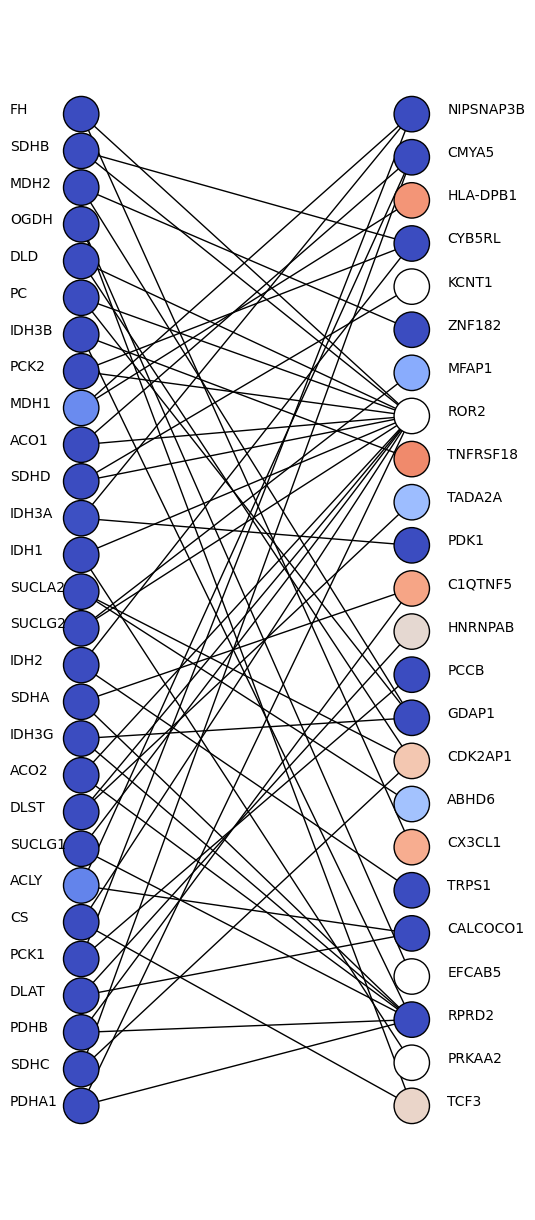

In [278]:
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms import bipartite

# 1. Create a graph object
B = nx.Graph()

# 2. Add nodes with the 'bipartite' attribute
# Assuming 'genes' and 'diseases' are your two sets
genes = tca_genes
diseases = related_genes
B.add_nodes_from(genes, bipartite=0)
B.add_nodes_from(diseases, bipartite=1)

# 3. Add edges (only between opposite sets)
B.add_edges_from(edges)

# 4. Define the position using a bipartite layout
top_nodes = {n for n, d in B.nodes(data=True) if d['bipartite'] == 0}
pos = nx.bipartite_layout(B, top_nodes)

plt.figure(figsize=(4, 12))

# 5. Draw the graph
nx.draw(B, pos, with_labels=False, node_color=[colors[node] for node in B.nodes()], node_size=650, font_size=8, edgecolors='black')



pos=nx.bipartite_layout(B, top_nodes, align='horizontal')


for node, d in B.nodes(data=True):
    y, x = pos[node]
    if d["bipartite"]:
        plt.text(x + 0.2, y, s=node) #, bbox=dict(facecolor='red', alpha=0.5),horizontalalignment='center')
    else:
        plt.text(x - 0.4, y, s=node) #, bbox=dict(facecolor='red', alpha=0.5),horizontalalignment='center')
    
    
    # print(x,y, node)
plt.show()
